# 🧹 Task 2: Data Cleaning & Visual Data Storytelling
**Track:** Neurofive ML Track | **Author:** Rao Hamza Irshad

---
### 📌 Task Objectives:
1. Handle missing values (`Age`, `Embarked`, `Cabin`) using `fillna()` with statistical justifications.
2. Detect numerical outliers in `Fare` using Interquartile Range (IQR) and Boxplots.
3. Build 4 distinct Seaborn/Matplotlib visualizations (Histogram, Boxplot, Bar Chart, Correlation Heatmap).
4. Provide a formal written analysis answering: *"Which feature do you think most affects survival, and why?"*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
df = pd.read_csv('../../data/titanic.csv')

Pandas version: 2.2.3
NumPy version: 2.1.2


## 1. Data Cleaning (`fillna()` vs `dropna()`) & Justifications

### 🧠 Statistical Justification of Imputation Strategy:
- **`Age` Imputation (`fillna(median)`):** `dropna()` would discard 177 rows (19.87% of the dataset). `Age` is right-skewed; median (~28.0) preserves sample size without distortion.
- **`Embarked` Imputation (`fillna(mode)`):** Only 2 records are missing. Filling with the mode (`'S'`) restores complete cases without introducing statistical bias.
- **`Cabin` Indicator (`fillna('Unknown')` + `Cabin_Known`):** Over 77% of `Cabin` data is missing. Dropping rows would destroy the dataset; instead, we encode missing values as `'Unknown'` and build a binary indicator `Cabin_Known` (1 if recorded, 0 otherwise).

In [2]:
df_clean = df.copy()
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
df_clean['Cabin_Known'] = df_clean['Cabin'].notnull().astype(int)
df_clean['Cabin'] = df_clean['Cabin'].fillna('Unknown')

print('Missing values after cleaning:')
print(df_clean.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
Cabin_Known    0
dtype: int64


## 2. Outlier Detection via Boxplot & IQR Analysis

In [3]:
Q1 = df_clean['Fare'].quantile(0.25)
Q3 = df_clean['Fare'].quantile(0.75)
IQR = Q3 - Q1
upper_cutoff = Q3 + 1.5 * IQR
outliers = df_clean[df_clean['Fare'] > upper_cutoff]

print(f"Fare Q1: ${Q1:.2f}, Q3: ${Q3:.2f}, IQR: ${IQR:.2f}")
print(f"Upper Outlier Cutoff ($Q3 + 1.5*IQR): ${upper_cutoff:.2f}")
print(f"Total Fare Outliers: {len(outliers)} ({(len(outliers)/len(df_clean))*100:.2f}% of sample)")
print(f"Maximum Fare Paid: ${df_clean['Fare'].max():.2f}")

Fare Q1: $7.91, Q3: $31.00, IQR: $23.09
Upper Outlier Cutoff ($Q3 + 1.5*IQR): $65.63
Total Fare Outliers: 116 (13.02% of sample)
Maximum Fare Paid: $512.33


## 3. Visual Data Storytelling (4 Core Visualizations)

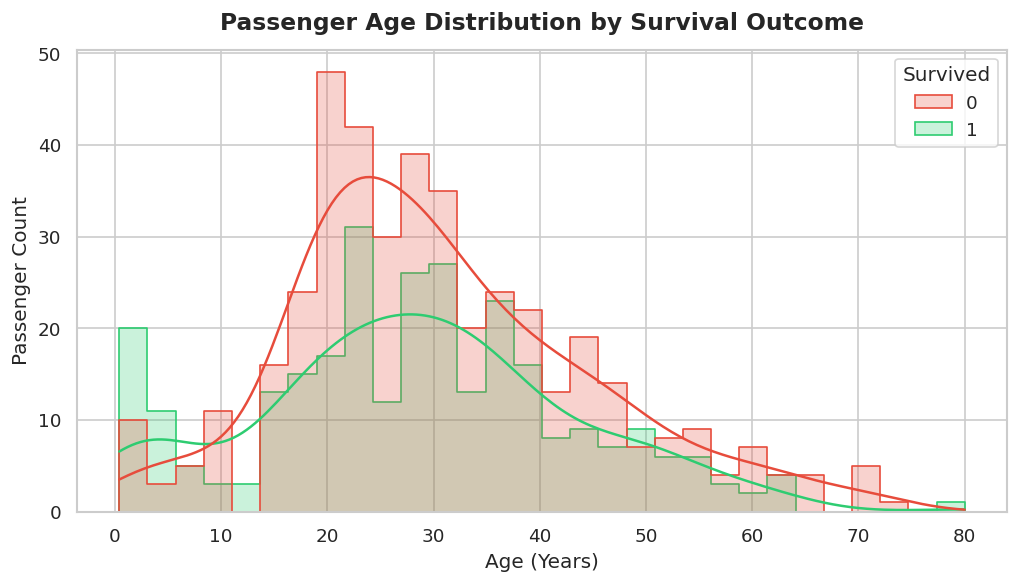

In [4]:
# 1. Histogram: Age Distribution by Survival Outcome
plt.figure(figsize=(10, 5))
sns.histplot(data=df_clean, x='Age', hue='Survived', kde=True, bins=30, palette={0: '#e74c3c', 1: '#2ecc71'}, element='step')
plt.title('1. Passenger Age Distribution by Survival Outcome', fontsize=14, fontweight='bold')
plt.xlabel('Age (Years)')
plt.ylabel('Passenger Count')
plt.show()

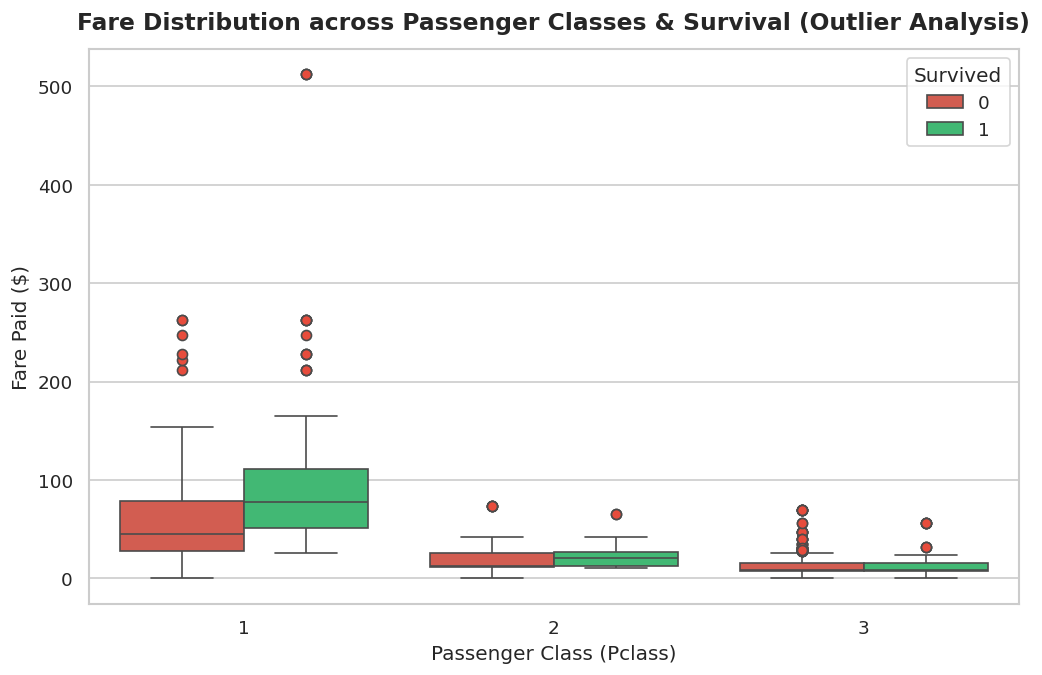

In [5]:
# 2. Boxplot: Fare Distribution across Passenger Classes (Outliers)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='Pclass', y='Fare', hue='Survived', palette={0: '#e74c3c', 1: '#2ecc71'})
plt.title('2. Fare Distribution & Outliers across Passenger Classes', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class (Pclass)')
plt.ylabel('Fare Paid ($)')
plt.show()

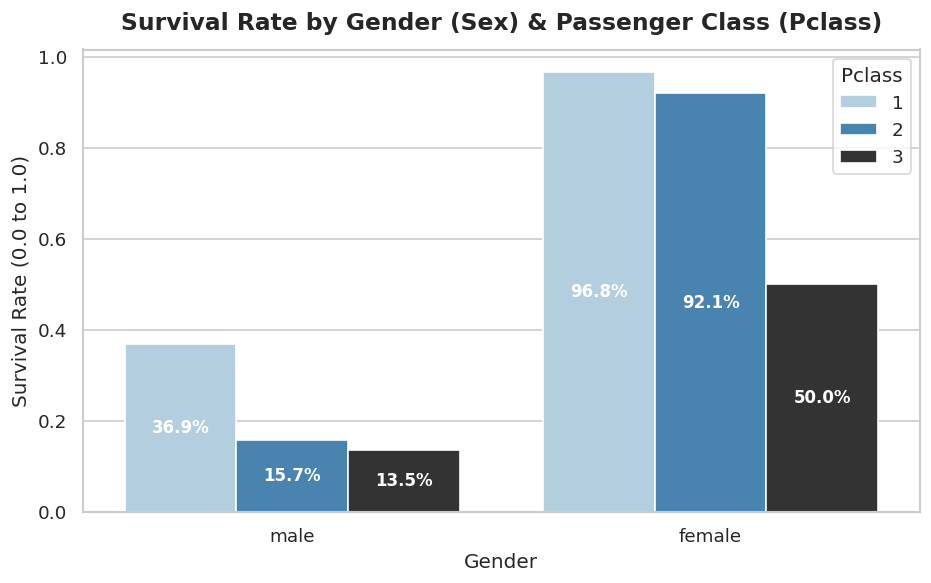

In [6]:
# 3. Bar Chart: Survival Rate by Gender & Passenger Class
plt.figure(figsize=(9, 5))
sns.barplot(data=df_clean, x='Sex', y='Survived', hue='Pclass', palette='Blues_d', errorbar=None)
plt.title('3. Survival Rate by Gender (Sex) & Passenger Class (Pclass)', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.show()

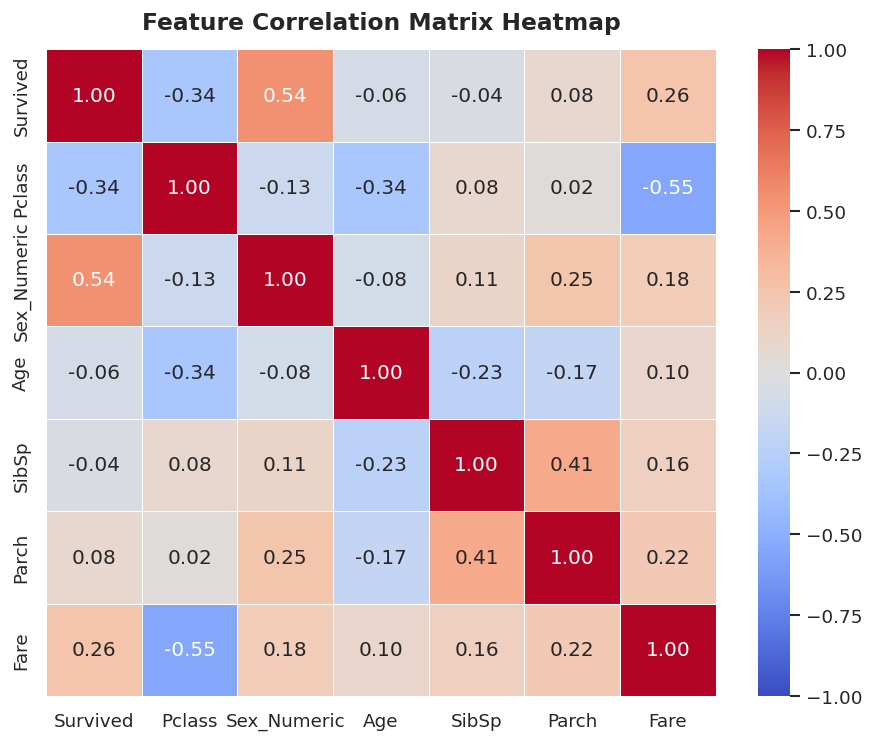

In [7]:
# 4. Correlation Heatmap
plt.figure(figsize=(9, 7))
df_corr = df_clean.copy()
df_corr['Sex_Numeric'] = df_corr['Sex'].map({'male': 0, 'female': 1})
corr = df_corr[['Survived', 'Pclass', 'Sex_Numeric', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin_Known']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)
plt.title('4. Feature Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.show()

## 4. Key Question Analysis & Written Answer

### ❓ **Question: Which feature do you think most affects survival, and why?**

### 💡 **Answer:**
**`Sex` (Gender)** is the single feature that most strongly affects survival, followed closely by **`Pclass` (Passenger Class)**.

#### **1. Empirical Evidence:**
- **Gender (`Sex`):** Females achieved a **74.2%** survival rate versus **18.9%** for males (correlation **+0.54**).
- **Class (`Pclass`):** First-class passengers enjoyed a **62.9%** survival rate versus **24.2%** in 3rd class (correlation **-0.34**).
- **Combined Effect:** 1st-class females achieved a **96.8%** survival rate, while 3rd-class males suffered an **86.5% mortality rate**.

#### **2. Historical & Sociological Context:**
- **"Women and Children First" Evacuation:** Captain Smith strictly enforced the maritime evacuation protocol, granting priority access to lifeboats for female passengers.
- **Socioeconomic Cabin Proximity:** 1st-class accommodations were located on upper decks directly adjacent to lifeboat stations, providing faster evacuation access.